In [38]:
import torch
from transformers import AutoModelForCausalLM
from transformers import AutoTokenizer, EsmForMaskedLM
from tokenizers import Tokenizer
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import os
import csv

from scipy.stats import spearmanr

In [2]:
from plm_compare_progen2 import *
from protein_data import *

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

model_name = "hugohrban/progen2-medium"
model, tokenizer = initialize_progen2(model_name)

Using cpu device


In [6]:
def wild_type(mut_name, sequence):

    mut_list = mut_name.split(":")

    for x in mut_list:
        mut = x
        len_mut = len(mut)
        orig = mut[0]
        pos = int(mut[1:len_mut-1])-1
        new = mut[len_mut-1]

        if new==sequence[pos]:
            # print(f"Position {pos + 1} changed from {new} to {orig}.")
            wild_seq = sequence[:pos] + orig + sequence[pos+1:]
        else:
            return f"Amino acid {new} not in position {pos + 1}."
        
    return wild_seq
    

In [20]:
AA = list("ACDEFGHIKLMNPQRSTVWY")
aa_to_idx = {aa: i for i, aa in enumerate(AA)}

directory = "/Users/johnhutchens/Desktop/Practicum/Data/zInput_Data/DMS_ProteinGym_substitutions"

pg_dict = dict()

for filename in os.listdir(directory):
    if filename.lower().endswith(".csv"):

        filename_list = filename.rsplit(".", 1)[0]
        parts = filename_list.split("_")

        if len(parts) >= 2:
            name = "_".join(parts[:2])

        filepath = os.path.join(directory, filename)

        with open(filepath, newline="", encoding="utf-8") as f:

            reader = csv.reader(f)
            next(reader, None)
            first_row = next(reader, None)
            wild = wild_type(first_row[0], first_row[1])

            n = len(wild)

            DMS = np.full((n, 20), np.nan)
            for row in reader:
                mut = row[0]
                #print(mut)
                if ":" not in mut:
                    index0 = int(mut[1:-1]) - 1
                    index1 = aa_to_idx[mut[-1]]
                    #print(index0, mut[-1], index1)
                    DMS[index0, index1] = row[2]
            
            pg_dict[name] = {'sequence': wild, 'DMS': DMS}
            
            

In [25]:
for key in list(pg_dict.keys()):

    print(pg_dict[key]['DMS'].shape,
    len(pg_dict[key]['sequence']) )

(44, 20) 44
(402, 20) 402
(553, 20) 553
(220, 20) 220
(346, 20) 346
(805, 20) 805
(757, 20) 757
(258, 20) 258
(128, 20) 128
(536, 20) 536
(248, 20) 248
(150, 20) 150
(286, 20) 286
(372, 20) 372
(577, 20) 577
(860, 20) 860
(66, 20) 66
(2016, 20) 2016
(61, 20) 61
(72, 20) 72
(54, 20) 54
(759, 20) 759
(72, 20) 72
(370, 20) 370
(67, 20) 67
(505, 20) 505
(198, 20) 198
(177, 20) 177
(770, 20) 770
(63, 20) 63
(393, 20) 393
(40, 20) 40
(364, 20) 364
(47, 20) 47
(159, 20) 159
(656, 20) 656
(635, 20) 635
(48, 20) 48
(934, 20) 934
(1278, 20) 1278
(852, 20) 852
(287, 20) 287
(55, 20) 55
(352, 20) 352
(55, 20) 55
(72, 20) 72
(3423, 20) 3423
(118, 20) 118
(448, 20) 448
(414, 20) 414
(61, 20) 61
(709, 20) 709
(66, 20) 66
(86, 20) 86
(465, 20) 465
(264, 20) 264
(589, 20) 589
(627, 20) 627
(70, 20) 70
(716, 20) 716
(211, 20) 211
(724, 20) 724
(861, 20) 861
(101, 20) 101
(93, 20) 93
(212, 20) 212
(71, 20) 71
(188, 20) 188
(281, 20) 281
(69, 20) 69
(490, 20) 490
(58, 20) 58
(565, 20) 565
(582, 20) 582
(7

In [35]:
keys = list(pg_dict.keys())

for i in range(len(keys)):
    key = keys[i]
    seq = pg_dict[key]['sequence']
    if len(seq) <= 1024:
        lp, rlp, llr = collect_log_prob_pg2(seq, model, tokenizer)
        pg_dict[key]['log_probs'] = lp
        pg_dict[key]['ref_log_probs'] = rlp
        pg_dict[key]['llr_matrix'] = llr




In [44]:
DMS = pg_dict[keys[43]]['DMS']
LLR = pg_dict[keys[43]]['llr_matrix']
seq = pg_dict[keys[43]]['sequence']

In [46]:
print(seq)
print(DMS[7])
print()
print(LLR[7])

MDYQVSSPIYDINYYTSEPCQKINVKQIAARLLPPLYSLVFIFGFVGNMLVILILINCKRLKSMTDIYLLNLAISDLFFLLTVPFWAHYAAAQWDFGNTMCQLLTGLYFIGFFSGIFFIILLTIDRYLAVVHAVFALKARTVTFGVVTSVITWVVAVFASLPGIIFTRSQKEGLHYTCSSHFPYSQYQFWKNFQTLKIVILGLVLPLLVMVICYSGILKTLLRCRNEKKRHRAVRLIFTIMIVYFLFWAPYNIVLLLNTFQEFFGLNNCSSSNRLDQAMQVTETLGMTHCCINPIIYAFVGEKFRNYLLVFFQKHIAKRFCKCCSIFQQEAPERASSVYTRSTGEQEISVGL
[ 0.62   0.185 -0.225  0.345 -0.085  0.36   0.03   0.39  -0.465  0.215
  0.605 -0.145    nan -0.285  0.295  0.2   -0.4    0.07   1.02  -0.08 ]

[-0.7832947  -2.2640533   0.45414734 -0.0201416  -0.81272125 -0.5348511
 -1.335556   -0.9325714  -1.3621521  -0.36053467 -2.022766   -0.5345917
  0.         -0.9281845  -1.34375     0.5877379   0.1368866  -0.88384247
 -2.2954788  -0.34999084]


In [37]:
path = '/Users/johnhutchens/Desktop/Practicum/Data/Wild_Dictionaries/'
filename = 'pg2_ProGym_matrices.pickle' 

with open(path + filename, 'wb') as f:
    pickle.dump(pg_dict, f, protocol=pickle.HIGHEST_PROTOCOL)

In [53]:
def spearman_ignore_nan(a, b):
    mask = ~np.isnan(a) & ~np.isnan(b)
    return spearmanr(a[mask], b[mask])

In [60]:
x = pg_dict[keys[43]]['DMS'][20]
y = pg_dict[keys[43]]['llr_matrix'][20]

corr, p_value = spearman_ignore_nan(x, y)

In [61]:
corr

np.float64(0.11940303109371317)

In [81]:
sp_list = []
n = len(pg_dict[keys[25]]['sequence'])

for i in range(n):
    x = pg_dict[keys[25]]['DMS'][i]
    y = pg_dict[keys[25]]['llr_matrix'][i]

    corr, p_value = spearman_ignore_nan(x, y)

    sp_list.append(corr)

/var/folders/30/5r4_75_n4bz34nyphw8tfv3m0000gn/T/ipykernel_3088/467302619.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


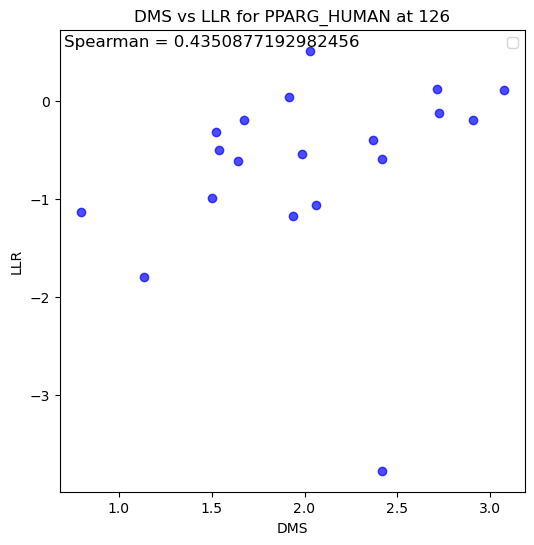

In [87]:
i = 25
j = 125

x = pg_dict[keys[i]]['DMS'][j]
y = pg_dict[keys[i]]['llr_matrix'][j]

mask = ~np.isnan(x) & ~np.isnan(y)
x_clean = x[mask]
y_clean = y[mask]

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x_clean, y_clean, color='blue', alpha=0.7)
plt.xlabel("DMS")
plt.ylabel("LLR")
plt.title(f"DMS vs LLR for {keys[i]} at {j+1}")
plt.grid(False)
plt.gca().text(
    0.01, 0.99,                # (0,1) = top-left in axes coordinates
    f"Spearman = {sp_list[j]}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    horizontalalignment='left',
)
#plt.text(0, 0, f"Spearman = {sp_list[j]}", fontsize=12, color='red')
# # Optional: add identity line y=x
# min_val = min(x_clean.min(), y_clean.min())
# max_val = max(x_clean.max(), y_clean.max())
# plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y=x')

plt.legend()
plt.show()

In [67]:
sp_list

[np.float64(-0.1719298245614035),
 np.float64(0.2263157894736842),
 np.float64(0.38421052631578945),
 np.float64(-0.2982456140350877),
 np.float64(-0.20526315789473687),
 np.float64(0.368421052631579),
 np.float64(-0.46315789473684205),
 np.float64(-0.5190918472652218),
 np.float64(0.6263157894736843),
 np.float64(-0.0945054945054945),
 np.float64(0.11867905056759545),
 np.float64(-0.03921568627450981),
 np.float64(0.642857142857143),
 np.float64(-0.42002063983488136),
 np.float64(0.0543859649122807),
 np.float64(0.482843137254902),
 np.float64(-0.4021978021978022),
 np.float64(0.2070175438596491),
 np.float64(-0.20949432404540763),
 np.float64(-0.08088235294117649),
 np.float64(0.11578947368421051),
 np.float64(-0.2631578947368421),
 np.float64(-0.24736842105263157),
 np.float64(-0.11403508771929824),
 np.float64(0.38095238095238104),
 np.float64(-0.502450980392157),
 np.float64(-0.22456140350877193),
 np.float64(-0.24912280701754386),
 np.float64(0.2142857142857143),
 np.float64(-0.3

In [3]:
df_otc_h = pd.read_csv('/Users/johnhutchens/Desktop/Practicum/Data/DMS_ProteinGym_substitutions/OTC_HUMAN_Lo_2023.csv')

In [4]:
df_otc_h.head()

,mutant,mutated_sequence,DMS_score,DMS_score_bin
0,A102E,MLFNLRILLNNAAFRNGHNFMVRNFRCGQPLQNKVQLKGRDLLTLK...,0.438,1
1,A102G,MLFNLRILLNNAAFRNGHNFMVRNFRCGQPLQNKVQLKGRDLLTLK...,0.676,1
2,A102P,MLFNLRILLNNAAFRNGHNFMVRNFRCGQPLQNKVQLKGRDLLTLK...,0.153,0
3,A102S,MLFNLRILLNNAAFRNGHNFMVRNFRCGQPLQNKVQLKGRDLLTLK...,0.948,1
4,A102T,MLFNLRILLNNAAFRNGHNFMVRNFRCGQPLQNKVQLKGRDLLTLK...,0.861,1


In [16]:
mut = df_otc_h.iloc[0]['mutant']
seq = df_otc_h.iloc[0]['mutated_sequence']
print(mut)
print(seq)

A102E
MLFNLRILLNNAAFRNGHNFMVRNFRCGQPLQNKVQLKGRDLLTLKNFTGEEIKYMLWLSADLKFRIKQKGEYLPLLQGKSLGMIFEKRSTRTRLSTETGFELLGGHPCFLTTQDIHLGVNESLTDTARVLSSMADAVLARVYKQSDLDTLAKEASIPIINGLSDLYHPIQILADYLTLQEHYSSLKGLTLSWIGDGNNILHSIMMSAAKFGMHLQAATPKGYEPDASVTKLAEQYAKENGTKLLLTNDPLEAAHGGNVLITDTWISMGQEEEKKKRLQAFQGYQVTMKTAKVAASDWTFLHCLPRKPEEVDDEVFYSPRSLVFPEAENRKWTIMAVMVSLLTDYSPQLQKPKF


In [34]:
len_mut = len(mut)
orig = mut[0]
pos = int(mut[1:len_mut-1])-1
new = mut[len_mut-1]

In [35]:
wild_seq = seq[:pos] + orig + seq[pos+1:]

In [38]:
print(seq[101])
wild_seq[101]

E


'A'

In [23]:
with open('/Users/johnhutchens/Desktop/Practicum/Data/OTC_Human/pg2_otc_hum_matrices.pickle',
           'rb') as f:
    pg_dict = pickle.load(f)

In [39]:
pg_dict[None] = {'mutated_sequence': wild_seq}

In [40]:
pg_dict[None]

{'mutated_sequence': 'MLFNLRILLNNAAFRNGHNFMVRNFRCGQPLQNKVQLKGRDLLTLKNFTGEEIKYMLWLSADLKFRIKQKGEYLPLLQGKSLGMIFEKRSTRTRLSTETGFALLGGHPCFLTTQDIHLGVNESLTDTARVLSSMADAVLARVYKQSDLDTLAKEASIPIINGLSDLYHPIQILADYLTLQEHYSSLKGLTLSWIGDGNNILHSIMMSAAKFGMHLQAATPKGYEPDASVTKLAEQYAKENGTKLLLTNDPLEAAHGGNVLITDTWISMGQEEEKKKRLQAFQGYQVTMKTAKVAASDWTFLHCLPRKPEEVDDEVFYSPRSLVFPEAENRKWTIMAVMVSLLTDYSPQLQKPKF'}